# Download Data

In [11]:
import os
import math

!pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)
if not os.path.exists('/content/roiRLT.zip'):
    link = '1wZvZXR8IfMsUbNTXHksbDBi4dF94LSXn'  # Restricted shared link
    downloaded = drive.CreateFile({'id':link}) 
    downloaded.GetContentFile('roiRLT.zip')

!unzip roiRLT.zip

Archive:  roiRLT.zip
replace __MACOSX/._roiRLT? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace roiRLT/Rlt_Roi9.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


# Main

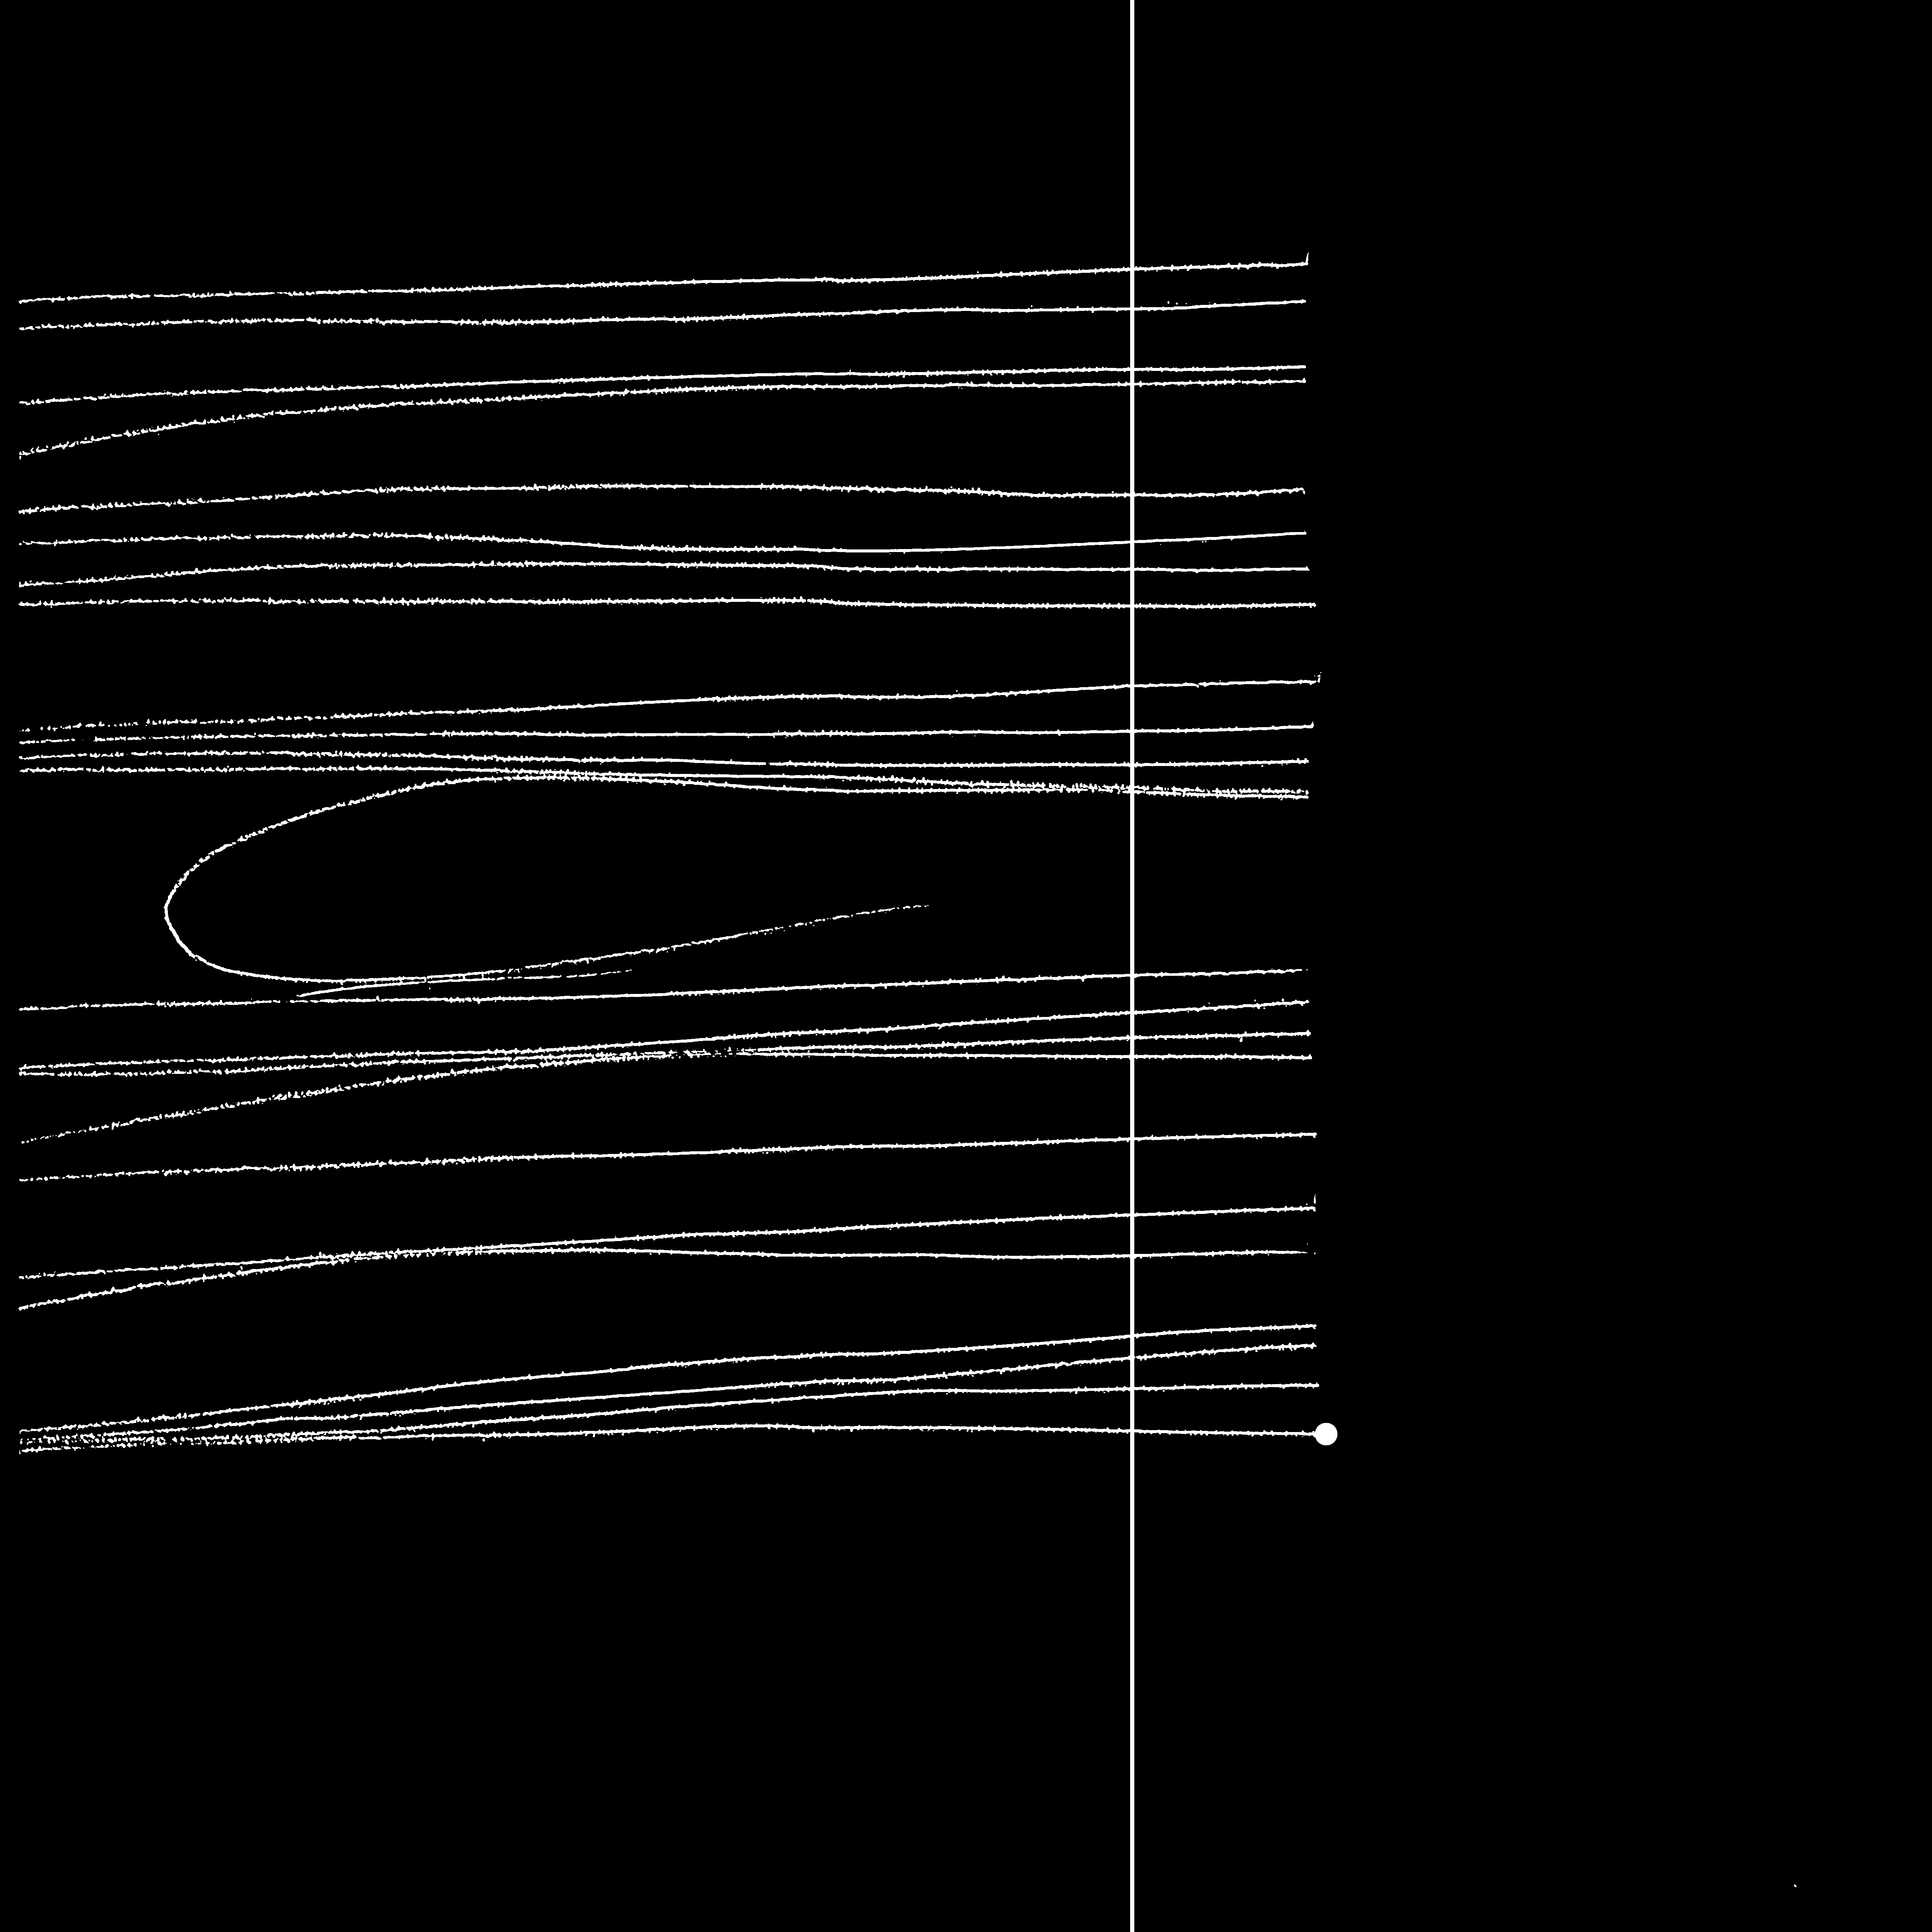

In [7]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
 
img = cv2.imread("/content/roiRLT/Rlt_Roi5.jpg")
inputImageGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
thresh = 10
im_bw = cv2.threshold(inputImageGray, thresh, 255, cv2.THRESH_BINARY)[1]
im_test = cv2.threshold(inputImageGray, thresh, 255, cv2.THRESH_BINARY)[1]


x_test,y_test = 3450,300

start_point = (3000, 0)
  
# End coordinate, here (250, 250)
# represents the bottom right corner of image
end_point = (3000, 5120)
  
# Green color in BGR
color = 255
  
# Line thickness of 9 px
thickness = 9
  
# Using cv2.line() method
# Draw a diagonal green line with thickness of 9 px
im_test = cv2.line(im_test, start_point, end_point, color, thickness)




center_coordinates = (3514,3800)
 
# Radius of circle
radius = 30
  
# Red color in BGR
color = 255
  
# Line thickness of -1 px
thickness = -1
  
# Using cv2.circle() method
# Draw a circle of red color of thickness -1 px
im_test = cv2.circle(im_test, center_coordinates, radius, color, thickness)


cv2_imshow(im_test)
# cv2_imshow(im_bw)

## STEP 1: 获取起始端点
从右往左用竖线遍历，当遇到第一个高亮白点时，将其标识为第一个直线的起始点，接着使用区域生长获取以此端点为起点的直线路径。

In [14]:
def getStartPoint(img):
    """getStartPoint
    获取起始端点，从右往左用竖线遍历，当遇到第一个高亮白点时，将其标识为第一个直线的起始点，接着使用区域生长获取以此端点为起点的直线路径。
    Args:
        img (numpy.ndarray): A binary img read by cv2
    Returns:
        startPoint (tuple): A tuple with coordinates (x, y) of the first startPoint
    """
    startPoint = []
    endPointFlag = False
    width = img.shape[1]
    height = img.shape[0]
    for x in range(width-1,-1,-1):
        for y in range(height):
            if img[y,x] > 0:
                if isEndPoint(img,(x, y)):
                    startPoint.append((x, y))
                    endPointFlag = True
                    break
        if endPointFlag:
            break
    
    return startPoint


def isEndPoint(img, point, threshold=0.8):
    """isEndPoint
    判断是否是直线的端点
    Args:
        img (numpy.ndarray): A binary img read by cv2
        point (tuple): coordinates (x, y) of the point
        threshold (int): the threshold percentage of the EndPoint determination. Default 0.5
    Returns:
        (Bool): is or not a end point
    """
    neibPoints = getLeftNeibPoints(point)
    count = 0 #记录白色点的数量 
    for (x,y) in neibPoints:
        if isInImg(img,(x,y)):
            if img[y,x] > 0:
                count += 1
    if count/len(neibPoints) > threshold:
        return True
    else:
        return False

def getLeftNeibPoints(point, width=30, height=2):
    """getLeftNeibPoints
    以输入点的矩形右侧边中点, 宽度和长度分别为width, height的矩形内的所有点
    Args:
        point (tuple): coordinates (x, y) of the center of circle
        raidus (int): the raidus of the circle
    Returns:
        neibPoints (list): list of tuples with coordinates (x, y) of the points in the around circle.
    """
    neibPoints = []
    x_point, y_point = point
    min_x, max_x = x_point - width, x_point
    min_y, may_y = y_point - height//2, y_point + height//2
    for x in range(min_x, max_x, 1):
        for y in range(min_y, may_y, 1):
            neibPoints.append((x,y))
    return neibPoints

def isInImg(img, point):
    """isInImg
    判断点是否在图片中
    Args:
        img (numpy.ndarray): A binary img read by cv2
        point (tuple): coordinates (x, y) of the point
    Returns:
        (Bool): is or not in the image
    """
    shape_y, shape_x = img.shape
    x, y = point
    if x > shape_x-1 or x < 0 and y > shape_y-1 or y < 0:
        return False
    else:
        return True

In [15]:
getStartPoint(im_bw)

[(3514, 3800)]

## STEP 2: 区域生长
整体思路如下图所示，通过当前起始点判断行进方向的窗口中白色点的数量，来识别行进方向。

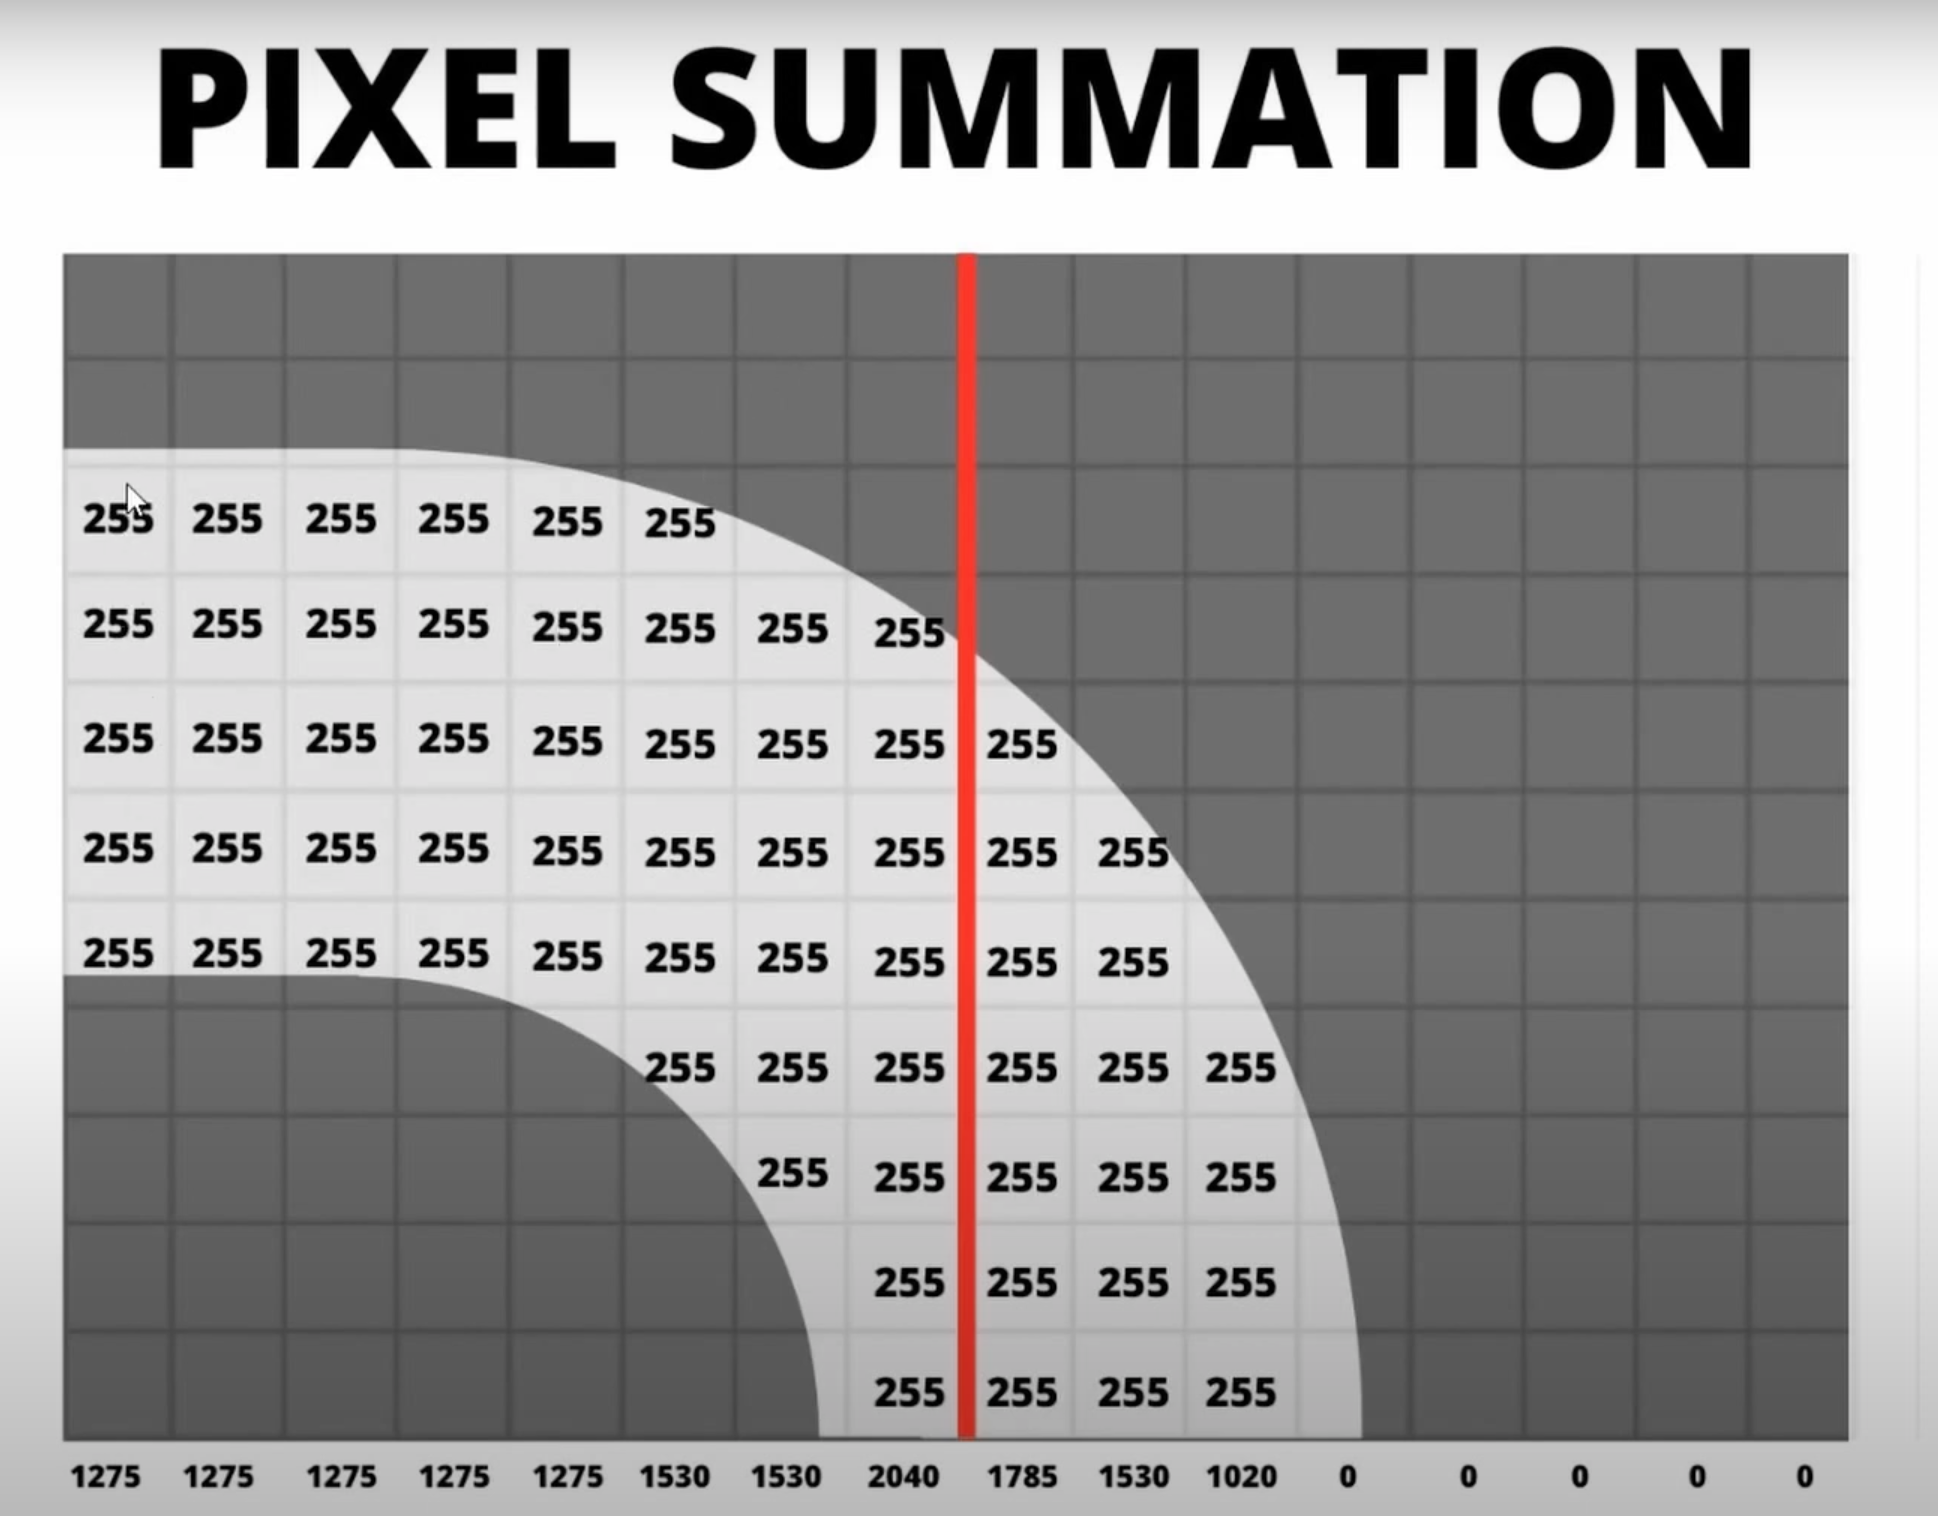

In [ ]:
def regionGrowing(img, startPoint):
    """regionGrowing
    从起始点向左侧探索，若路线是往下偏移，则path添加往下的点，若路线是往上偏移，则path添加往上的点。
    Args:
        img (numpy.ndarray): A binary img read by cv2
        startPoint (numpy.ndarray): A 2-dim ndarray with shape (x, y), x, y are the location of the startPoint.
    Returns:
        path (numpy.ndarray): A 3-dim ndarray with shape (N, x, y), where N is the number of points in the path, 
                                    x, y are the coordinates of the corresponding point.
    """
    path = []
    startDirection = (-1,0) # 探索方向，以向量来表示，初始值为向左，每层循环都把此值更新为上一个点作为起点与当前点作为终点的构成的向量
    while startPoint != None:
        #### STEP 0 把当前点加入path
        path.append(startPoint)
        
        #### STEP 1 找到当前点面前对应的区域 width=100, height=50,
        facingBlock = findFacingBlock(img, startPoint, startDirection)

        #### STEP 2 Pixel summation 统计白色pixel在facingBlock的startDirection方向的垂直维度上的数量
        pixelHist = pixelSummation(facingBlock, startPoint, startDirection)

        #### STEP 3 通过pixel Histgram，计算得出行走方向，并得出下一个点的位置
        nextPoint, direction = calNextStep(pixelHist, startPoint)

        #### SETP 4 更新起始探索点和探索方向
        startPoint = nextPoint
        startDirection = direction

    return path

In [16]:
startPoints = getStartPoint(im_bw)
for (x,y) in startPoints:
    regionGrowing(im_bw, startPoints)
    print(x,y)

3514 3800


## STEP3: 曲线拟合

## STEP4: 处理特殊情况